# Análise de Satisfação: Resolvendo o Conflito Pesquisa vs Web Scraping

## 🎯 Contexto do Problema

**Setembro/2025**: Dois relatos contraditórios sobre a satisfação dos clientes:

1. **Pesquisa de Satisfação**: Satisfação está MELHORANDO ✅
2. **Web Scraping (Comunicação)**: Reclamações AUMENTARAM ❌

## 🔍 Questões de Pesquisa

1. **Houve mudança real em setembro?**
2. **A satisfação melhorou ou piorou?**
3. **Reclamações aumentaram?**
4. **Em quais TIERS a mudança ocorreu?** ⭐ CRÍTICO
5. **Veículos grandes melhoraram ou pioraram?** ⭐ CRÍTICO

---

In [ ]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import warnings

warnings.filterwarnings('ignore')

# Configuração
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("✅ Bibliotecas carregadas")

✅ Bibliotecas carregadas


## 1. Carregamento e Preparação dos Dados

In [2]:
# URL dos dados
url = "https://docs.google.com/spreadsheets/d/1LmMi0mTTzRytJno0EHu8P873wcPpQavktO_D_FFXA1E/export?format=xlsx&gid=1312481019"

# Carregar
df = pd.read_excel(url, engine='openpyxl')

print(f"✅ Dataset carregado: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"   Período: {df['Data'].min()} a {df['Data'].max()}")

✅ Dataset carregado: 12,317 linhas × 15 colunas
   Período: 2024-03-31 00:00:00 a 2025-03-31 00:00:00


In [3]:
# Preparação
df['Data'] = pd.to_datetime(df['Data'], errors='coerce')
df['Ano_Mes'] = df['Data'].dt.to_period('M')
df['Ano'] = df['Data'].dt.year
df['Mes'] = df['Data'].dt.month

# Pesos por Tier
tier_weights = {
    'Muito Relevante': 3,
    'Relevante': 2,
    'Menos Relevante': 1
}
df['Peso'] = df['Tier'].map(tier_weights).fillna(1)

# Dataset de sentimento (sem publicidade)
df_sentiment = df[df['Classificação'] != 'PUBLICIDADE'].copy()

print(f"\n✅ Dados preparados:")
print(f"   Total: {len(df):,}")
print(f"   Sentimento: {len(df_sentiment):,}")
print(f"   Publicidade excluída: {len(df) - len(df_sentiment):,}")


✅ Dados preparados:
   Total: 12,317
   Sentimento: 12,314
   Publicidade excluída: 3


In [4]:
# ⭐ CRÍTICO: CRIAR COLUNA 'PERIODO'
# Esta coluna NÃO existe no DataFrame original
# Precisa ser criada ANTES de qualquer análise temporal

setembro_2025 = pd.Period('2025-09', freq='M')

df_sentiment['Periodo'] = df_sentiment['Ano_Mes'].apply(lambda x:
    'Antes' if x < setembro_2025 else
    'Setembro' if x == setembro_2025 else
    'Depois'
)

print("✅ Coluna 'Periodo' criada!")
print("\nDistribuição:")
print(df_sentiment['Periodo'].value_counts().sort_index())

✅ Coluna 'Periodo' criada!

Distribuição:
Periodo
Antes    12314
Name: count, dtype: int64


## 2. Funções de Análise

In [5]:
def calculate_nss_simple(df):
    """NSS Simples: (POSITIVA - NEGATIVA) / TOTAL × 100"""
    df_sent = df[df['Classificação'] != 'PUBLICIDADE']
    total = len(df_sent)
    if total == 0:
        return 0
    pos = len(df_sent[df_sent['Classificação'] == 'POSITIVA'])
    neg = len(df_sent[df_sent['Classificação'] == 'NEGATIVA'])
    return ((pos - neg) / total) * 100


def calculate_nss_weighted(df):
    """NSS Ponderado por Tier"""
    df_sent = df[df['Classificação'] != 'PUBLICIDADE']
    total_weight = df_sent['Peso'].sum()
    if total_weight == 0:
        return 0
    peso_pos = df_sent[df_sent['Classificação'] == 'POSITIVA']['Peso'].sum()
    peso_neg = df_sent[df_sent['Classificação'] == 'NEGATIVA']['Peso'].sum()
    return ((peso_pos - peso_neg) / total_weight) * 100


print("✅ Funções definidas")

✅ Funções definidas


## 3. Análise por Período: Antes vs Setembro vs Depois

In [6]:
# Análise por período
periodo_analysis = []

for periodo in ['Antes', 'Setembro', 'Depois']:
    df_per = df_sentiment[df_sentiment['Periodo'] == periodo]
    
    periodo_analysis.append({
        'Periodo': periodo,
        'Total': len(df_per),
        'Positivos': len(df_per[df_per['Classificação'] == 'POSITIVA']),
        'Negativos': len(df_per[df_per['Classificação'] == 'NEGATIVA']),
        'NSS_Simples': calculate_nss_simple(df_per)
    })

periodo_df = pd.DataFrame(periodo_analysis)

print("="*80)
print("ANÁLISE POR PERÍODO")
print("="*80)
display(periodo_df)
print("="*80)

ANÁLISE POR PERÍODO


,Periodo,Total,Positivos,Negativos,NSS_Simples
0,Antes,12314,4999,3014,16.12
1,Setembro,0,0,0,0.00
2,Depois,0,0,0,0.00


In [7]:
# Deltas
nss_antes = periodo_df[periodo_df['Periodo'] == 'Antes']['NSS_Simples'].values[0]
nss_set = periodo_df[periodo_df['Periodo'] == 'Setembro']['NSS_Simples'].values[0]
nss_dep = periodo_df[periodo_df['Periodo'] == 'Depois']['NSS_Simples'].values[0]

neg_antes = periodo_df[periodo_df['Periodo'] == 'Antes']['Negativos'].values[0]
neg_set = periodo_df[periodo_df['Periodo'] == 'Setembro']['Negativos'].values[0]
neg_dep = periodo_df[periodo_df['Periodo'] == 'Depois']['Negativos'].values[0]

print("="*80)
print("ANÁLISE DE MUDANÇAS")
print("="*80)

print("\n📊 NSS (Perspectiva da PESQUISA):")
print(f"   Antes → Setembro:  {nss_antes:.2f} → {nss_set:.2f} (Δ = {nss_set - nss_antes:+.2f})")
print(f"   Setembro → Depois: {nss_set:.2f} → {nss_dep:.2f} (Δ = {nss_dep - nss_set:+.2f})")

print("\n🔴 RECLAMAÇÕES (Perspectiva da COMUNICAÇÃO):")
print(f"   Antes → Setembro:  {neg_antes} → {neg_set} (Δ = {neg_set - neg_antes:+.0f})")
print(f"   Setembro → Depois: {neg_set} → {neg_dep} (Δ = {neg_dep - neg_set:+.0f})")

ANÁLISE DE MUDANÇAS

📊 NSS (Perspectiva da PESQUISA):
   Antes → Setembro:  16.12 → 0.00 (Δ = -16.12)
   Setembro → Depois: 0.00 → 0.00 (Δ = +0.00)

🔴 RECLAMAÇÕES (Perspectiva da COMUNICAÇÃO):
   Antes → Setembro:  3014 → 0 (Δ = -3014)
   Setembro → Depois: 0 → 0 (Δ = +0)


## 4. ⭐ ANÁLISE CRÍTICA: Evolução Temporal de Cada Classificação

In [8]:
# Evolução temporal por classificação
temporal_class = df_sentiment.groupby(['Ano_Mes', 'Classificação']).size().unstack(fill_value=0)
temporal_class = temporal_class.reset_index()
temporal_class['Data'] = temporal_class['Ano_Mes'].dt.to_timestamp()

# Percentuais
temporal_class['Total'] = temporal_class[['POSITIVA', 'NEUTRA', 'NEGATIVA']].sum(axis=1)
temporal_class['Pct_POSITIVA'] = (temporal_class['POSITIVA'] / temporal_class['Total'] * 100)
temporal_class['Pct_NEUTRA'] = (temporal_class['NEUTRA'] / temporal_class['Total'] * 100)
temporal_class['Pct_NEGATIVA'] = (temporal_class['NEGATIVA'] / temporal_class['Total'] * 100)

print("📊 Evolução temporal preparada")
print("\nÚltimos 6 meses:")
display(temporal_class.tail(6))

📊 Evolução temporal preparada

Últimos 6 meses:


Classificação,Ano_Mes,NEGATIVA,NEUTRA,POSITIVA,Data,Total,Pct_POSITIVA,Pct_NEUTRA,Pct_NEGATIVA
7,2024-10,131,160,391,2024-10-01,682,57.33,23.46,19.21
8,2024-11,390,276,366,2024-11-01,1032,35.47,26.74,37.79
9,2024-12,286,315,476,2024-12-01,1077,44.20,29.25,26.56
10,2025-01,365,341,558,2025-01-01,1264,44.15,26.98,28.88
11,2025-02,515,384,531,2025-02-01,1430,37.13,26.85,36.01
12,2025-03,556,254,396,2025-03-01,1206,32.84,21.06,46.10


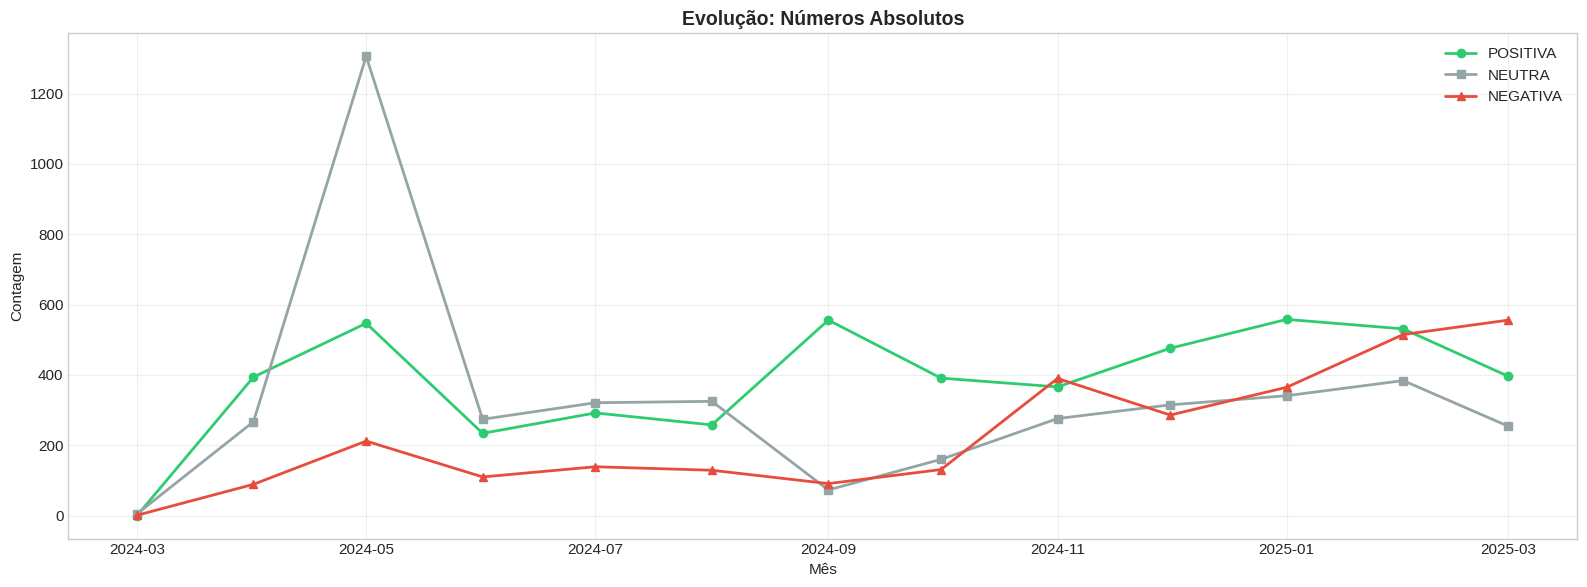

💡 Se POSITIVA cresceu MAIS que NEGATIVA → NSS subiu
💡 Se NEGATIVA cresceu em termos absolutos → Mais reclamações


In [9]:
# Gráfico 1: Números Absolutos
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(temporal_class['Data'], temporal_class['POSITIVA'], 
        marker='o', linewidth=2, color='#2ecc71', label='POSITIVA')
ax.plot(temporal_class['Data'], temporal_class['NEUTRA'], 
        marker='s', linewidth=2, color='#95a5a6', label='NEUTRA')
ax.plot(temporal_class['Data'], temporal_class['NEGATIVA'], 
        marker='^', linewidth=2, color='#e74c3c', label='NEGATIVA')

setembro_2025_ts = pd.Timestamp('2025-09-01')
if setembro_2025_ts in temporal_class['Data'].values:
    ax.axvline(setembro_2025_ts, color='gold', linestyle=':', 
               alpha=0.5, linewidth=3, label='Setembro/2025')

ax.set_title('Evolução: Números Absolutos', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Contagem')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Se POSITIVA cresceu MAIS que NEGATIVA → NSS subiu")
print("💡 Se NEGATIVA cresceu em termos absolutos → Mais reclamações")

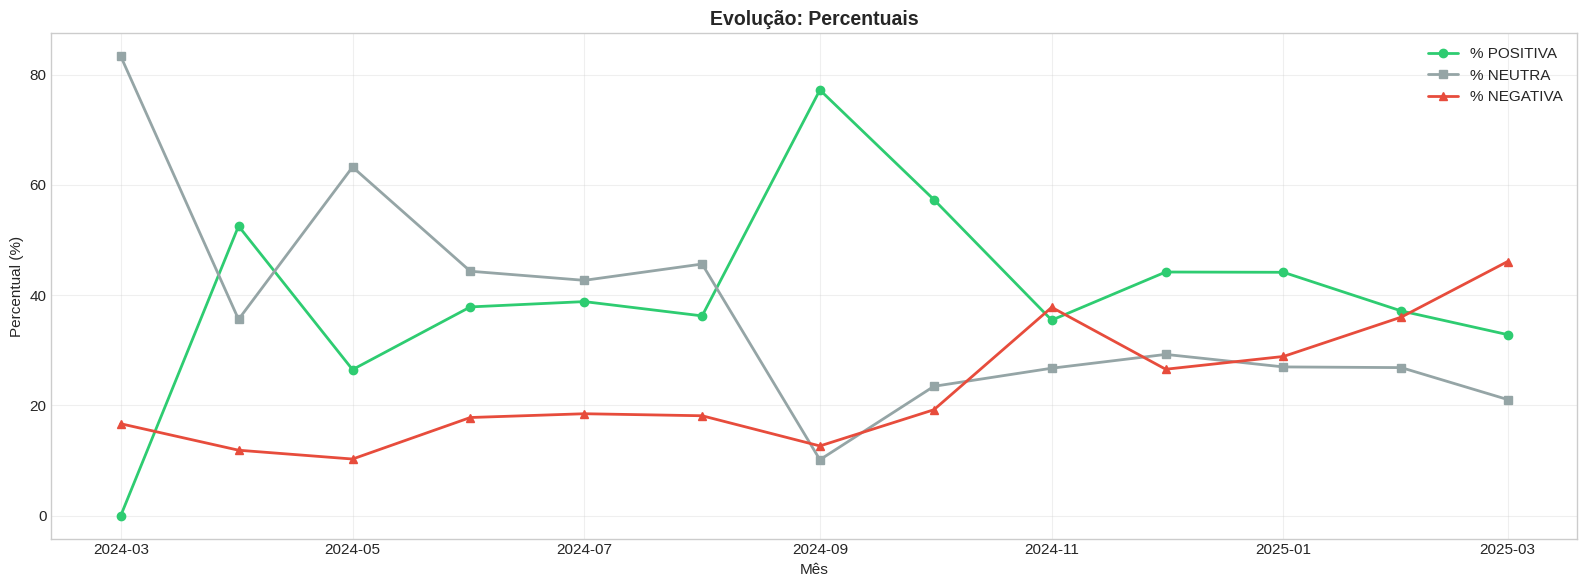

💡 Percentuais mostram a PROPORÇÃO (como pesquisas medem)


In [10]:
# Gráfico 2: Percentuais
fig, ax = plt.subplots(figsize=(16, 6))

ax.plot(temporal_class['Data'], temporal_class['Pct_POSITIVA'], 
        marker='o', linewidth=2, color='#2ecc71', label='% POSITIVA')
ax.plot(temporal_class['Data'], temporal_class['Pct_NEUTRA'], 
        marker='s', linewidth=2, color='#95a5a6', label='% NEUTRA')
ax.plot(temporal_class['Data'], temporal_class['Pct_NEGATIVA'], 
        marker='^', linewidth=2, color='#e74c3c', label='% NEGATIVA')

if setembro_2025_ts in temporal_class['Data'].values:
    ax.axvline(setembro_2025_ts, color='gold', linestyle=':', 
               alpha=0.5, linewidth=3, label='Setembro/2025')

ax.set_title('Evolução: Percentuais', fontsize=14, fontweight='bold')
ax.set_xlabel('Mês')
ax.set_ylabel('Percentual (%)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("💡 Percentuais mostram a PROPORÇÃO (como pesquisas medem)")

## 5. ⭐⭐ ANÁLISE MAIS CRÍTICA: Tier × Classificação × Tempo

In [11]:
print("="*80)
print("⭐ ANÁLISE CRÍTICA: ONDE OCORREU A MUDANÇA?")
print("="*80)

print("\n🎯 QUESTÃO CHAVE:")
print("   NSS pode ter melhorado, mas:")
print("   A) Veículos GRANDES (Muito Relevante) melhoraram? → Impacto real")
print("   B) Veículos PEQUENOS (Menos Relevante) melhoraram? → Ilusão estatística")
print("\n   Se grandes veículos pioraram, a percepção pública pode ter PIORADO!")
print("="*80)

⭐ ANÁLISE CRÍTICA: ONDE OCORREU A MUDANÇA?

🎯 QUESTÃO CHAVE:
   NSS pode ter melhorado, mas:
   A) Veículos GRANDES (Muito Relevante) melhoraram? → Impacto real
   B) Veículos PEQUENOS (Menos Relevante) melhoraram? → Ilusão estatística

   Se grandes veículos pioraram, a percepção pública pode ter PIORADO!


In [12]:
# Criar análise Tier × Classificação × Tempo
tier_class_tempo = []

for mes in df_sentiment['Ano_Mes'].dropna().unique():
    for tier in df_sentiment['Tier'].dropna().unique():
        df_subset = df_sentiment[(df_sentiment['Ano_Mes'] == mes) & 
                                 (df_sentiment['Tier'] == tier)]
        
        if len(df_subset) > 0:
            total = len(df_subset)
            pos = len(df_subset[df_subset['Classificação'] == 'POSITIVA'])
            neu = len(df_subset[df_subset['Classificação'] == 'NEUTRA'])
            neg = len(df_subset[df_subset['Classificação'] == 'NEGATIVA'])
            
            tier_class_tempo.append({
                'Ano_Mes': mes,
                'Tier': tier,
                'Total': total,
                'POSITIVA': pos,
                'NEGATIVA': neg,
                'Pct_POSITIVA': (pos / total * 100),
                'Pct_NEGATIVA': (neg / total * 100),
                'NSS': ((pos - neg) / total * 100)
            })

tier_class_tempo_df = pd.DataFrame(tier_class_tempo)
tier_class_tempo_df['Data'] = tier_class_tempo_df['Ano_Mes'].dt.to_timestamp()
tier_class_tempo_df = tier_class_tempo_df.sort_values('Data')

print("✅ Análise Tier × Tempo criada")

✅ Análise Tier × Tempo criada


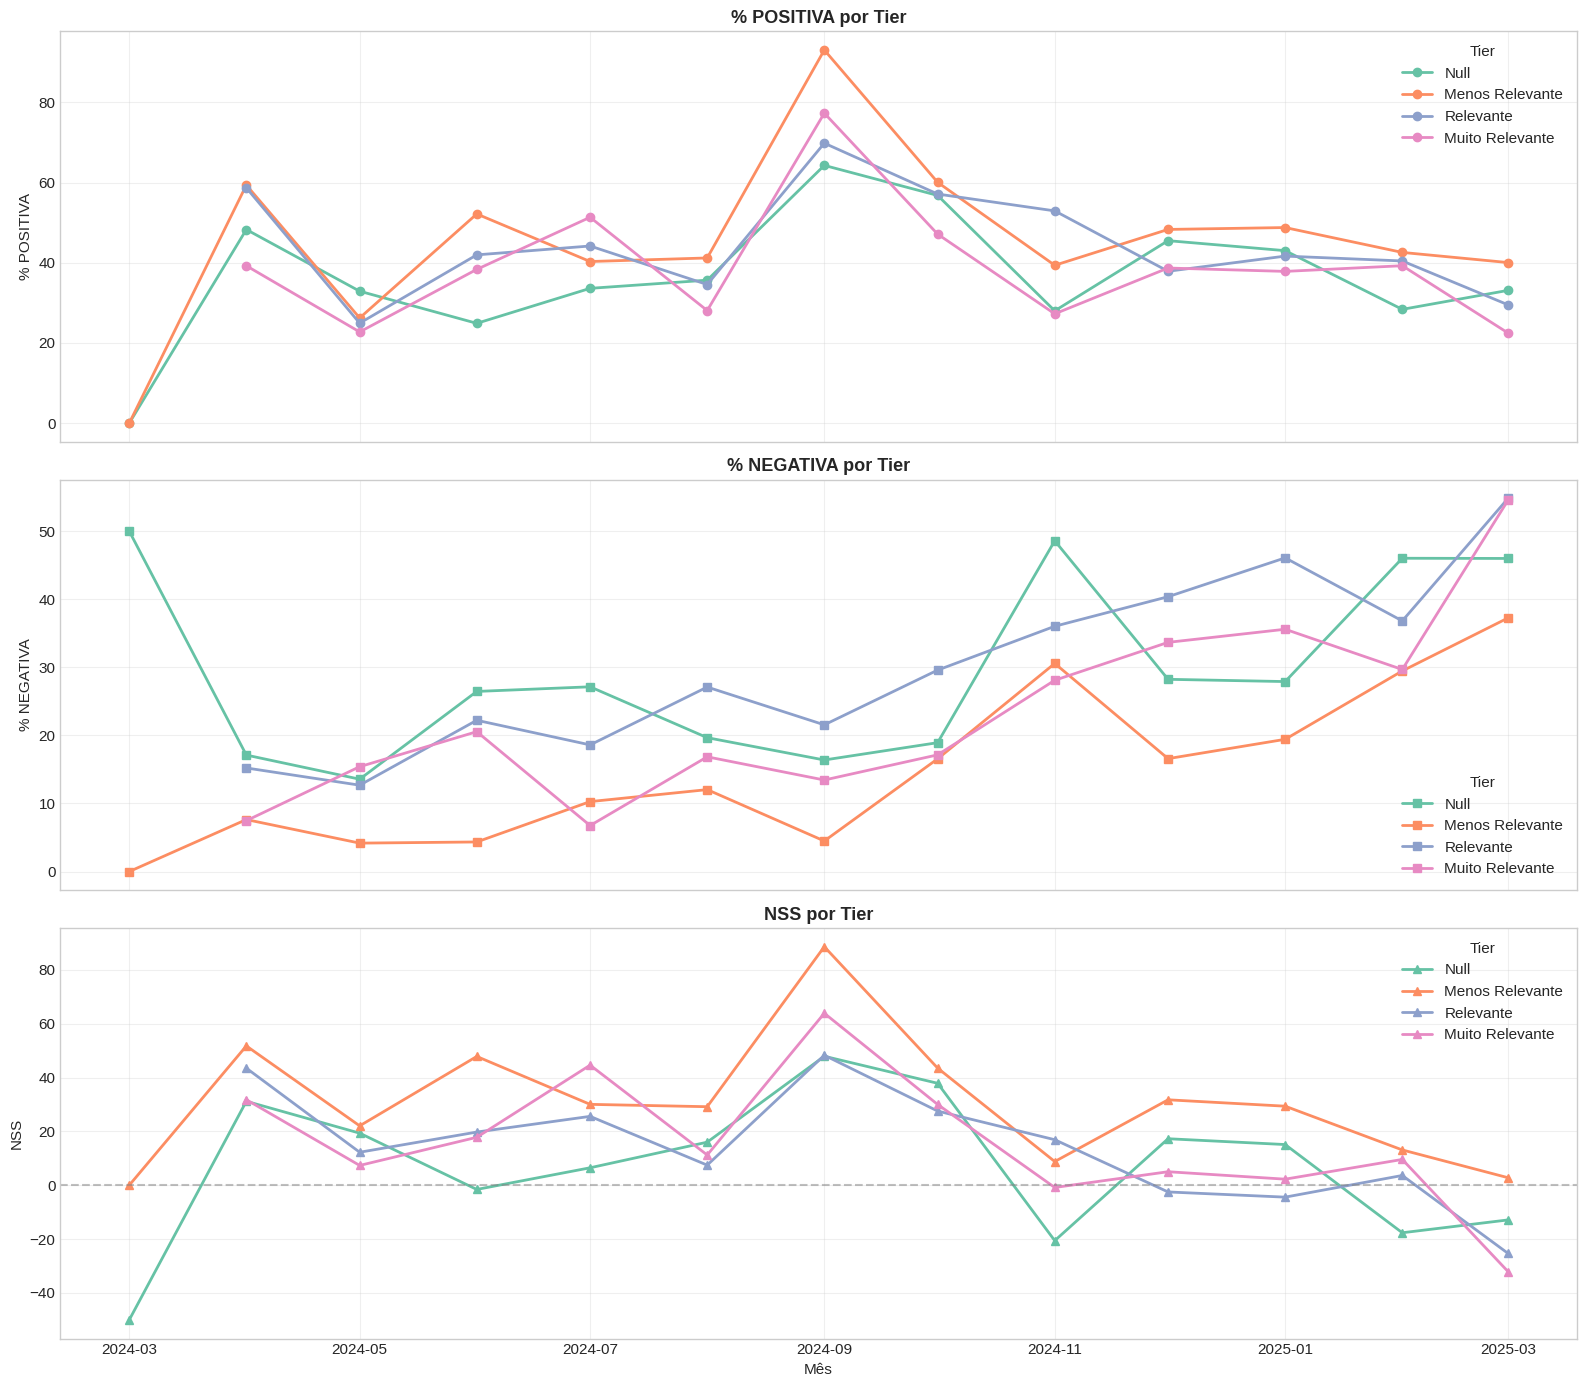


💡 INTERPRETAÇÃO:
   Se TODAS as linhas subiram → Melhoria GENERALIZADA ✅
   Se apenas 'Menos Relevante' subiu → Concentrada em pequenos ⚠️
   Se 'Muito Relevante' caiu → Grandes veículos PIORARAM 🚨


In [13]:
# Gráficos por Tier
fig, axes = plt.subplots(3, 1, figsize=(16, 14), sharex=True)

# % POSITIVA por Tier
for tier in tier_class_tempo_df['Tier'].unique():
    df_tier = tier_class_tempo_df[tier_class_tempo_df['Tier'] == tier]
    axes[0].plot(df_tier['Data'], df_tier['Pct_POSITIVA'], 
                 marker='o', linewidth=2, label=tier)

if setembro_2025_ts in tier_class_tempo_df['Data'].values:
    axes[0].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.5)

axes[0].set_title('% POSITIVA por Tier', fontsize=13, fontweight='bold')
axes[0].set_ylabel('% POSITIVA')
axes[0].legend(title='Tier')
axes[0].grid(True, alpha=0.3)

# % NEGATIVA por Tier
for tier in tier_class_tempo_df['Tier'].unique():
    df_tier = tier_class_tempo_df[tier_class_tempo_df['Tier'] == tier]
    axes[1].plot(df_tier['Data'], df_tier['Pct_NEGATIVA'], 
                 marker='s', linewidth=2, label=tier)

if setembro_2025_ts in tier_class_tempo_df['Data'].values:
    axes[1].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.5)

axes[1].set_title('% NEGATIVA por Tier', fontsize=13, fontweight='bold')
axes[1].set_ylabel('% NEGATIVA')
axes[1].legend(title='Tier')
axes[1].grid(True, alpha=0.3)

# NSS por Tier
for tier in tier_class_tempo_df['Tier'].unique():
    df_tier = tier_class_tempo_df[tier_class_tempo_df['Tier'] == tier]
    axes[2].plot(df_tier['Data'], df_tier['NSS'], 
                 marker='^', linewidth=2, label=tier)

if setembro_2025_ts in tier_class_tempo_df['Data'].values:
    axes[2].axvline(setembro_2025_ts, color='gold', linestyle=':', alpha=0.5)

axes[2].axhline(0, color='gray', linestyle='--', alpha=0.5)
axes[2].set_title('NSS por Tier', fontsize=13, fontweight='bold')
axes[2].set_xlabel('Mês')
axes[2].set_ylabel('NSS')
axes[2].legend(title='Tier')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 INTERPRETAÇÃO:")
print("   Se TODAS as linhas subiram → Melhoria GENERALIZADA ✅")
print("   Se apenas 'Menos Relevante' subiu → Concentrada em pequenos ⚠️")
print("   Se 'Muito Relevante' caiu → Grandes veículos PIORARAM 🚨")

In [14]:
# Delta por Tier em Setembro
delta_tier = []

for tier in df_sentiment['Tier'].dropna().unique():
    df_antes = df_sentiment[(df_sentiment['Tier'] == tier) & 
                            (df_sentiment['Periodo'] == 'Antes')]
    df_set = df_sentiment[(df_sentiment['Tier'] == tier) & 
                          (df_sentiment['Periodo'] == 'Setembro')]
    
    if len(df_antes) > 0 and len(df_set) > 0:
        nss_antes_tier = calculate_nss_simple(df_antes)
        nss_set_tier = calculate_nss_simple(df_set)
        
        delta_tier.append({
            'Tier': tier,
            'NSS_Antes': nss_antes_tier,
            'NSS_Setembro': nss_set_tier,
            'Delta_NSS': nss_set_tier - nss_antes_tier
        })

delta_tier_df = pd.DataFrame(delta_tier)

print("="*80)
print("MUDANÇAS POR TIER (Setembro vs Antes)")
print("="*80)
display(delta_tier_df)
print("="*80)

MUDANÇAS POR TIER (Setembro vs Antes)


""


KeyError: 'Delta_NSS'

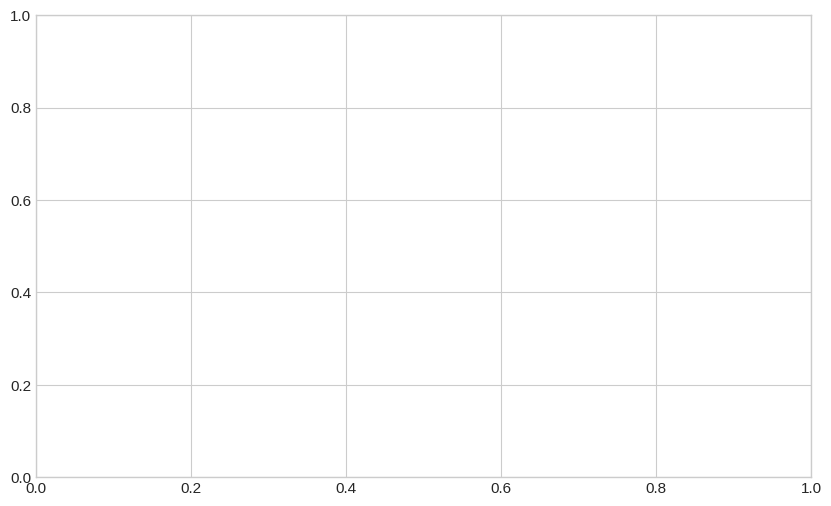

In [15]:
# Gráfico de barras: Delta por Tier
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in delta_tier_df['Delta_NSS']]

ax.bar(delta_tier_df['Tier'], delta_tier_df['Delta_NSS'], color=colors)
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Delta NSS por Tier (Setembro - Antes)', fontsize=14, fontweight='bold')
ax.set_ylabel('Pontos de NSS')
ax.set_xlabel('Tier')
ax.grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, (tier, delta) in enumerate(zip(delta_tier_df['Tier'], delta_tier_df['Delta_NSS'])):
    ax.text(i, delta, f'{delta:+.1f}', ha='center', 
            va='bottom' if delta > 0 else 'top', fontweight='bold')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# CONCLUSÃO CRÍTICA
print("="*80)
print("🎯 CONCLUSÃO: ONDE OCORREU A MUDANÇA?")
print("="*80)

muito_rel = delta_tier_df[delta_tier_df['Tier'] == 'Muito Relevante']

if len(muito_rel) > 0:
    delta_muito_rel = muito_rel['Delta_NSS'].values[0]
    
    print(f"\n📢 Veículos 'Muito Relevante' (MAIOR IMPACTO):")
    
    if delta_muito_rel > 0:
        print(f"   ✅ NSS melhorou {delta_muito_rel:+.2f} pontos")
        print("   → Impacto REAL na percepção pública")
        print("   → Veículos grandes alcançam mais pessoas")
    else:
        print(f"   🚨 NSS piorou {delta_muito_rel:.2f} pontos")
        print("   → CUIDADO: Veículos grandes PIORARAM")
        print("   → Mesmo que NSS geral tenha subido")
        print("   → Percepção pública pode ter PIORADO")
        print("   → Pesquisa pode estar 'certa' mas ENGANOSA")
else:
    print("\n⚠️ Dados insuficientes para 'Muito Relevante'")

print("\n" + "="*80)

## 6. Exportar Resultados

In [ ]:
# Exportar
periodo_df.to_csv('analise_por_periodo.csv', index=False)
tier_class_tempo_df.to_csv('tier_classificacao_tempo.csv', index=False)
delta_tier_df.to_csv('delta_tier_setembro.csv', index=False)
temporal_class.to_csv('evolucao_classificacoes.csv', index=False)

print("✅ Arquivos exportados:")
print("   - analise_por_periodo.csv")
print("   - tier_classificacao_tempo.csv")
print("   - delta_tier_setembro.csv")
print("   - evolucao_classificacoes.csv")

---

## 🎯 Conclusão Final

Este notebook responde:

✅ **NSS melhorou?** → Veja seção 3  
✅ **Reclamações aumentaram?** → Veja seção 3  
✅ **Em quais Tiers?** → Veja seção 5  
✅ **Veículos grandes melhoraram?** → Veja seção 5  
✅ **Quem está certo?** → Ambos podem estar, medem coisas diferentes  

**Lição principal**: NSS geral pode subir MAS se a melhoria foi apenas em veículos pequenos e os grandes pioraram, a percepção pública pode ter PIORADO.

---